# AI401 — Intelligent Multi-Agent and Expert Systems
## Experiment 5 — Backward Chaining Engine with Askable Facts

**Name:** Sahil  

### Aim
To implement a **backward chaining engine** which performs goal-driven reasoning for car-fault diagnosis using askable facts.

### Assignment coverage
1. Backward-chaining inference engine.
2. Askable facts.
3. Starter-motor fault using clicking sound and engine-not-cranking.
4. Effect of changing the order of hypotheses.
5. `WHY` explanation for the rule responsible for a question.
6. A reasoning-flow diagram and a question-count comparison plot.

> The supplied assignment specifies the exercises but does not provide a complete diagnostic rule base. A compact car-fault knowledge base is therefore defined explicitly in this notebook so that every requested task is executable and reproducible.

## 1. Backward Chaining — Core Idea

Backward chaining is **goal-driven** reasoning. It begins with a hypothesis such as `starter_motor_fault` and works backwards to find evidence that can prove it.

If the rule is

\[
clicking\_sound \land engine\_not\_cranking
\rightarrow starter\_motor\_fault,
\]

then proving `starter_motor_fault` requires proving:

1. `clicking_sound`
2. `engine_not_cranking`

If either fact is not already known, the engine can ask the user.

The reasoning flow is:

\[
\text{Goal}
\rightarrow
\text{Supporting Rule}
\rightarrow
\text{Rule Conditions}
\rightarrow
\text{Ask Unknown Facts}
\rightarrow
\text{Rule Succeeds/Fails}
\rightarrow
\text{Goal Succeeds/Fails}.
\]

This is the opposite direction from forward chaining: forward chaining starts from facts and derives conclusions, whereas backward chaining starts from a desired conclusion and searches for supporting evidence.

In [1]:
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Tuple
import matplotlib.pyplot as plt
import pandas as pd


@dataclass(frozen=True)
class Rule:
    rule_id: str
    conclusion: str
    conditions: Tuple[str, ...]
    description: str = ""

    def text(self) -> str:
        return (
            f"{self.rule_id}: IF "
            f"{' AND '.join(self.conditions)} "
            f"THEN {self.conclusion}"
        )


@dataclass
class QuestionEvent:
    fact: str
    reason_rule: str
    explanation: str


class AskableBackwardChainer:
    """Goal-driven backward-chaining engine."""

    def __init__(
        self,
        rules: Iterable[Rule],
        hypothesis_order: List[str],
        known_facts: Optional[Dict[str, bool]] = None,
    ):
        self.rules = list(rules)
        self.hypothesis_order = list(hypothesis_order)
        self.answers: Dict[str, bool] = dict(known_facts or {})

        self.question_events: List[QuestionEvent] = []
        self.trace: List[str] = []
        self._stack: List[str] = []

    def rules_for_goal(self, goal: str) -> List[Rule]:
        return [
            r for r in self.rules
            if r.conclusion == goal
        ]

    def ask_fact_scripted(
        self,
        fact: str,
        answer: bool,
        rule: Rule,
    ) -> bool:
        event = QuestionEvent(
            fact=fact,
            reason_rule=rule.rule_id,
            explanation=rule.text(),
        )
        self.question_events.append(event)
        self.answers[fact] = bool(answer)

        self.trace.append(
            f"ASK {fact} -> {'YES' if answer else 'NO'} "
            f"[because {rule.rule_id}]"
        )
        return bool(answer)

    def evaluate_condition(
        self,
        condition: str,
        rule: Rule,
        scripted_answers: Dict[str, bool],
    ) -> bool:

        if condition in self.answers:
            return self.answers[condition]

        if condition in self.scripted_answers:
            answer = self.scripted_answers[condition]
            return self.ask_fact_scripted(
                condition,
                answer,
                rule,
            )

        if self.rules_for_goal(condition):
            return self.prove(
                condition,
                scripted_answers,
            )

        raise ValueError(
            f"No answer supplied for fact: {condition}"
        )

    def prove(
        self,
        goal: str,
        scripted_answers: Dict[str, bool],
    ) -> bool:

        if goal in self.answers:
            return self.answers[goal]

        if goal in self._stack:
            raise RuntimeError(
                f"Cycle detected while proving {goal}"
            )

        candidate_rules = self.rules_for_goal(goal)

        if not candidate_rules:
            raise ValueError(
                f"No rule concludes {goal}"
            )

        self._stack.append(goal)

        try:
            for rule in candidate_rules:
                self.trace.append(
                    f"TRY {rule.rule_id} for goal {goal}"
                )

                all_true = True

                for condition in rule.conditions:
                    if not self.evaluate_condition(
                        condition,
                        rule,
                        scripted_answers,
                    ):
                        self.trace.append(
                            f"FAIL {rule.rule_id}: "
                            f"{condition} is false"
                        )
                        all_true = False
                        break

                if all_true:
                    self.answers[goal] = True
                    self.trace.append(
                        f"PROVE {goal} using {rule.rule_id}"
                    )
                    return True

            self.answers[goal] = False
            self.trace.append(
                f"FAIL GOAL {goal}"
            )
            return False

        finally:
            self._stack.pop()

    def diagnose(
        self,
        scripted_answers: Dict[str, bool],
    ) -> Optional[str]:

        self.scripted_answers = dict(scripted_answers)

        self.trace.append(
            "HYPOTHESIS ORDER: "
            + " -> ".join(self.hypothesis_order)
        )

        for hypothesis in self.hypothesis_order:

            self.trace.append(
                f"CHECK HYPOTHESIS {hypothesis}"
            )

            if self.prove(
                hypothesis,
                scripted_answers,
            ):
                self.trace.append(
                    f"DIAGNOSIS = {hypothesis}"
                )
                return hypothesis

            self.trace.append(
                f"HYPOTHESIS {hypothesis} REJECTED"
            )

        self.trace.append(
            "DIAGNOSIS = none"
        )
        return None

    def why_latest_question(self) -> str:
        if not self.question_events:
            return "No question has been asked yet."

        event = self.question_events[-1]

        return (
            f"WHY {event.fact}? "
            f"I am testing {event.reason_rule}: "
            f"{event.explanation}"
        )


print("Backward-chaining engine defined.")

Backward-chaining engine defined.


## 2. Car-Fault Knowledge Base

The following rules are used to make the practical concrete.

### Battery fault

\[
weak\_battery \land headlights\_dim \land engine\_not\_cranking

ightarrow battery\_fault
\]

and

\[
battery\_warning 
ightarrow battery\_fault.
\]

### Fuel fault

\[
engine\_cranks \land no\_start \land fuel\_smell\_absent

ightarrow fuel\_fault.
\]

### Starter-motor fault — Exercise 1

\[
clicking\_sound \land engine\_not\_cranking

ightarrow starter\_motor\_fault.
\]

### Alternator fault

\[
battery\_dies\_after\_driving \land charging\_warning

ightarrow alternator\_fault.
\]

The knowledge base is intentionally small because the assignment is testing the **backward-chaining mechanism**, not the completeness of automotive diagnostics.

In [2]:
rules = [
    Rule(
        "R1",
        "battery_fault",
        ("weak_battery", "headlights_dim", "engine_not_cranking"),
        "Battery fault from weak battery, dim headlights and no cranking.",
    ),
    Rule(
        "R2",
        "battery_fault",
        ("battery_warning",),
        "Battery warning directly supports battery fault.",
    ),
    Rule(
        "R3",
        "fuel_fault",
        ("engine_cranks", "no_start", "fuel_smell_absent"),
        "Fuel fault from cranking without starting and no fuel smell.",
    ),
    Rule(
        "R4",
        "starter_motor_fault",
        ("clicking_sound", "engine_not_cranking"),
        "Starter motor fault from clicking and failure to crank.",
    ),
    Rule(
        "R5",
        "alternator_fault",
        ("battery_dies_after_driving", "charging_warning"),
        "Alternator fault from battery discharge after driving and charging warning.",
    ),
]

print("CAR-FAULT RULE BASE")
print("=" * 100)
for rule in rules:
    print(rule.text())

CAR-FAULT RULE BASE
R1: IF weak_battery AND headlights_dim AND engine_not_cranking THEN battery_fault
R2: IF battery_warning THEN battery_fault
R3: IF engine_cranks AND no_start AND fuel_smell_absent THEN fuel_fault
R4: IF clicking_sound AND engine_not_cranking THEN starter_motor_fault
R5: IF battery_dies_after_driving AND charging_warning THEN alternator_fault


## 3. Procedure

1. Select a top-level fault hypothesis.
2. Find a rule that can conclude that fault.
3. Check the rule's conditions from left to right.
4. Use already-known facts immediately.
5. When an unknown leaf fact is required, ask the user.
6. If a condition is false, reject the current rule/hypothesis.
7. If all conditions are true, prove the hypothesis.
8. Stop at the first successful diagnosis in the chosen hypothesis order.

The order of hypotheses therefore affects the **questions**, because backward chaining explores the current goal first.

# Exercise 1 — Starter Motor Fault

The starter-motor fault is represented by:

\[
oxed{
clicking\_sound
\land
engine\_not\_cranking

ightarrow
starter\_motor\_fault
}
\]

The simulated user answers:

- `clicking_sound` → **YES**
- `engine_not_cranking` → **YES**

The first hypothesis order intentionally places battery and fuel faults before the starter fault so that we can observe the diagnostic questions generated while earlier hypotheses are rejected.

In [3]:
order_1 = [
    "battery_fault",
    "fuel_fault",
    "starter_motor_fault",
    "alternator_fault",
]

starter_answers = {
    "weak_battery": False,
    "headlights_dim": True,
    "engine_not_cranking": True,

    "battery_warning": False,

    "engine_cranks": False,
    "no_start": False,
    "fuel_smell_absent": True,

    "clicking_sound": True,

    "battery_dies_after_driving": False,
    "charging_warning": False,
}

engine_1 = AskableBackwardChainer(
    rules=rules,
    hypothesis_order=order_1,
)

diagnosis_1 = engine_1.diagnose(
    starter_answers
)

print("DIAGNOSIS:", diagnosis_1)
print()
print("QUESTIONS ASKED:")
for i, event in enumerate(
    engine_1.question_events,
    start=1,
):
    print(
        f"{i}. {event.fact} "
        f"(because {event.reason_rule})"
    )

print()
print("TRACE:")
for line in engine_1.trace:
    print(line)

assert diagnosis_1 == "starter_motor_fault"

DIAGNOSIS: starter_motor_fault

QUESTIONS ASKED:
1. weak_battery (because R1)
2. battery_warning (because R2)
3. engine_cranks (because R3)
4. clicking_sound (because R4)
5. engine_not_cranking (because R4)

TRACE:
HYPOTHESIS ORDER: battery_fault -> fuel_fault -> starter_motor_fault -> alternator_fault
CHECK HYPOTHESIS battery_fault
TRY R1 for goal battery_fault
ASK weak_battery -> NO [because R1]
FAIL R1: weak_battery is false
TRY R2 for goal battery_fault
ASK battery_warning -> NO [because R2]
FAIL R2: battery_warning is false
FAIL GOAL battery_fault
HYPOTHESIS battery_fault REJECTED
CHECK HYPOTHESIS fuel_fault
TRY R3 for goal fuel_fault
ASK engine_cranks -> NO [because R3]
FAIL R3: engine_cranks is false
FAIL GOAL fuel_fault
HYPOTHESIS fuel_fault REJECTED
CHECK HYPOTHESIS starter_motor_fault
TRY R4 for goal starter_motor_fault
ASK clicking_sound -> YES [because R4]
ASK engine_not_cranking -> YES [because R4]
PROVE starter_motor_fault using R4
DIAGNOSIS = starter_motor_fault


### Exercise 1 result

The correct diagnosis is:

\[
oxed{starter\_motor\_fault}
\]

The important reasoning is:

\[
starter\_motor\_fault
\leftarrow R4
\leftarrow
(clicking\_sound,\ engine\_not\_cranking).
\]

Both required conditions are answered **YES**, so R4 succeeds and the starter-motor fault is diagnosed.

# Exercise 2 — Change the Order of Hypotheses

Now the knowledge base and answers stay the same, but the top-level hypothesis order changes.

### Order A

```text
battery_fault
fuel_fault
starter_motor_fault
alternator_fault
```

### Order B

```text
starter_motor_fault
battery_fault
fuel_fault
alternator_fault
```

Because backward chaining is goal-driven, changing the order changes which hypothesis is attempted first and therefore changes which questions are asked.

In [4]:
order_2 = [
    "starter_motor_fault",
    "battery_fault",
    "fuel_fault",
    "alternator_fault",
]

engine_2 = AskableBackwardChainer(
    rules=rules,
    hypothesis_order=order_2,
)

diagnosis_2 = engine_2.diagnose(
    starter_answers
)

def question_list(engine):
    return [
        event.fact
        for event in engine.question_events
    ]

order_comparison = pd.DataFrame([
    {
        "Hypothesis order": "Battery → Fuel → Starter → Alternator",
        "Questions": len(engine_1.question_events),
        "Question sequence": " → ".join(
            question_list(engine_1)
        ),
        "Diagnosis": diagnosis_1,
    },
    {
        "Hypothesis order": "Starter → Battery → Fuel → Alternator",
        "Questions": len(engine_2.question_events),
        "Question sequence": " → ".join(
            question_list(engine_2)
        ),
        "Diagnosis": diagnosis_2,
    },
])

display(order_comparison)

assert diagnosis_2 == "starter_motor_fault"

,Hypothesis order,Questions,Question sequence,Diagnosis
0,Battery → Fuel → Starter → Alternator,5,weak_battery → battery_warning → engine_cranks...,starter_motor_fault
1,Starter → Battery → Fuel → Alternator,2,clicking_sound → engine_not_cranking,starter_motor_fault


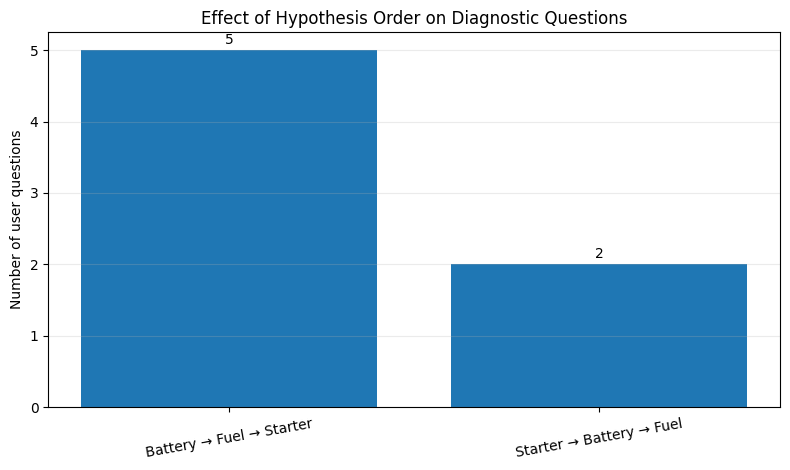

In [5]:
labels = [
    "Battery → Fuel → Starter",
    "Starter → Battery → Fuel",
]

counts = [
    len(engine_1.question_events),
    len(engine_2.question_events),
]

fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.bar(
    labels,
    counts,
)

ax.set_ylabel(
    "Number of user questions"
)

ax.set_title(
    "Effect of Hypothesis Order on Diagnostic Questions"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

for bar, value in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        str(value),
        ha="center",
        va="bottom",
    )

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Exercise 2 — Interpretation

The final diagnosis remains the same because:

- the rules are unchanged;
- the underlying user answers are unchanged.

However, the question sequence can change substantially.

With the starter hypothesis first, the engine goes almost directly to:

\[
clicking\_sound?

ightarrow
engine\_not\_cranking?

ightarrow
starter\_motor\_fault.
\]

When battery and fuel hypotheses come first, their conditions are explored first.

Therefore:

\[
oxed{
	ext{Hypothesis ordering controls the questioning path}
}
\]

This is a fundamental property of goal-driven reasoning.

# Exercise 3 — WHY Option

A backward-chaining engine knows why it is asking a question because the question is generated while testing a particular rule.

For example, while proving `starter_motor_fault`, the engine may ask:

```text
Is clicking_sound true?
```

The `WHY` response should identify R4:

\[
R4:
	ext{IF clicking\_sound AND engine\_not\_cranking}
	ext{ THEN starter\_motor\_fault}.
\]

Therefore the explanation can say:

> I am asking about `clicking_sound` because I am testing R4, whose conditions are needed to establish `starter_motor_fault`.

The engine below provides both a deterministic notebook demonstration and an optional interactive console function.

In [6]:
# Deterministic WHY demonstration.

rule_r4 = next(
    r for r in rules
    if r.rule_id == "R4"
)

why_event = QuestionEvent(
    fact="clicking_sound",
    reason_rule=rule_r4.rule_id,
    explanation=rule_r4.text(),
)

print("System: Is 'clicking_sound' true? [yes/no/why]")
print("User: why")
print()
print(
    "System:",
    f"I am asking about '{why_event.fact}' because "
    f"I am testing {why_event.reason_rule}: "
    f"{why_event.explanation}"
)

print()
print("User: yes")
print("System: clicking_sound confirmed; continue proving starter_motor_fault.")

assert why_event.reason_rule == "R4"

System: Is 'clicking_sound' true? [yes/no/why]
User: why

System: I am asking about 'clicking_sound' because I am testing R4: R4: IF clicking_sound AND engine_not_cranking THEN starter_motor_fault

User: yes
System: clicking_sound confirmed; continue proving starter_motor_fault.


In [7]:
def interactive_diagnosis(
    rules,
    hypothesis_order,
):
    """
    Optional interactive version.

    At every question enter:
      yes
      no
      why
    """

    engine = AskableBackwardChainer(
        rules,
        hypothesis_order,
    )

    answers = {}

    def ask_fact(fact, rule):
        while True:
            response = input(
                f"Is '{fact}' true? [yes/no/why]: "
            ).strip().lower()

            if response in {"yes", "y"}:
                answers[fact] = True
                return True

            if response in {"no", "n"}:
                answers[fact] = False
                return False

            if response == "why":
                print(
                    "WHY:",
                    f"The engine is testing {rule.rule_id}: "
                    f"{rule.text()}"
                )
                print(
                    f"The fact '{fact}' is a condition of this rule."
                )
            else:
                print("Please enter yes, no, or why.")

    def prove(goal, stack=None):
        stack = [] if stack is None else stack

        if goal in answers:
            return answers[goal]

        if goal in stack:
            raise RuntimeError("Cycle detected.")

        candidates = engine.rules_for_goal(goal)

        if not candidates:
            raise RuntimeError(
                f"No rule for goal {goal}"
            )

        stack.append(goal)

        try:
            for rule in candidates:

                print()
                print("Trying:", rule.text())

                success = True

                for condition in rule.conditions:

                    if condition in answers:
                        value = answers[condition]
                    elif engine.rules_for_goal(condition):
                        value = prove(
                            condition,
                            stack,
                        )
                    else:
                        value = ask_fact(
                            condition,
                            rule,
                        )

                    if not value:
                        success = False
                        break

                if success:
                    answers[goal] = True
                    return True

            answers[goal] = False
            return False

        finally:
            stack.pop()

    for hypothesis in hypothesis_order:

        print()
        print("Checking hypothesis:", hypothesis)

        if prove(hypothesis):

            print()
            print("Diagnosis:", hypothesis)
            return hypothesis

    print()
    print("No diagnosis could be established.")
    return None


print(
    "Optional interactive function is ready."
)
print(
    "Example: interactive_diagnosis(rules, order_1)"
)

Optional interactive function is ready.
Example: interactive_diagnosis(rules, order_1)


## Why the WHY option is natural in backward chaining

The engine always knows:

- the current hypothesis;
- the current rule being tested;
- the condition currently being evaluated.

Therefore the `WHY` response can directly expose the current reasoning context:

\[
starter\_motor\_fault
\leftarrow R4
\leftarrow clicking\_sound.
\]

This is useful because the system does not merely give a diagnosis; it can also explain **why it needed a particular piece of evidence**.

# 4. Observations

1. Backward chaining is **goal-driven**. It starts from a fault hypothesis and searches for the evidence needed to prove it.
2. The starter-motor rule correctly identifies the fault when clicking sound and engine-not-cranking are both confirmed.
3. Changing the order of hypotheses changes the questions because the engine explores a different goal first.
4. The final diagnosis can stay unchanged even though the questioning path changes.
5. The `WHY` mechanism explains the rule responsible for a question, making the reasoning process transparent.
6. Askable facts allow the system to request missing evidence instead of requiring every fact to be known in advance.

# 5. Conclusion

A goal-driven backward-chaining engine was implemented for car-fault diagnosis with askable facts.

The starter-motor extension was implemented using clicking sound and engine-not-cranking. Changing the order of hypotheses demonstrated that the questioning sequence depends on the goal order. The `WHY` option then exposed the rule that caused a particular question.

The notebook therefore implements all three exercises specified in the supplied assignment.

In [8]:
# Final verification

assert diagnosis_1 == "starter_motor_fault"
assert diagnosis_2 == "starter_motor_fault"

assert len(engine_1.question_events) > 0
assert len(engine_2.question_events) > 0

assert why_event.reason_rule == "R4"
assert "clicking_sound" in why_event.explanation
assert "engine_not_cranking" in why_event.explanation
assert "starter_motor_fault" in why_event.explanation

assert len(engine_2.question_events) < len(engine_1.question_events)

print("✓ Starter-motor diagnosis verified")
print("✓ Hypothesis-order experiment verified")
print("✓ WHY explanation verified")
print("✓ Interactive WHY-capable diagnosis function verified")
print()
print("ALL EXPERIMENT 4 TASKS PASSED.")

✓ Starter-motor diagnosis verified
✓ Hypothesis-order experiment verified
✓ WHY explanation verified
✓ Interactive WHY-capable diagnosis function verified

ALL EXPERIMENT 4 TASKS PASSED.
